# Dimensionality Reduction: PCA

This notebook is a **first-pass PCA baseline** for emotion classification.

What it does:
- loads one feature CSV
- separates metadata from model features
- trains a baseline model
- applies `PCA` on standardized training features
- retrains and compares performance
- visualizes explained variance by component
- saves PCA component names and transformed datasets

**Default dataset key for this notebook:** `ssl_hubert`


## 1) Imports and Notebook Settings

This cell sets up dependencies and plotting style.

In [1]:
from pathlib import Path
import json
import os
from contextlib import contextmanager

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from joblib import Parallel, delayed
from tqdm.auto import tqdm

plt.style.use('ggplot')
np.random.seed(42)

print('Imports loaded.')


Imports loaded.


## 2) Configuration

Pick which extracted feature table to run.

Recommended first run: `mfcc_raw` (fast and stable).

In [2]:
REPO_ROOT = Path.cwd().resolve().parents[2] if 'feature_selection' in str(Path.cwd()) else Path.cwd().resolve()

FEATURE_SOURCES = {
    'mfcc_raw': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features.csv',
    'mfcc_normalized': REPO_ROOT / 'extracted_features' / 'mfcc' / 'mfcc_features_normalized.csv',
    'prosody_energy': REPO_ROOT / 'extracted_features' / 'prosody_energy' / 'prosody_energy_features.csv',
    'prosody_pitch': REPO_ROOT / 'extracted_features' / 'prosody_pitch' / 'prosody_pitch_features.csv',
    'bert': REPO_ROOT / 'extracted_features' / 'text' / 'bert_embeddings.csv',
    'tfidf': REPO_ROOT / 'extracted_features' / 'text' / 'tfidf_features.csv',
    'ssl_hubert': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_hubert_features.csv',
    'ssl_wav2vec': REPO_ROOT / 'extracted_features' / 'ssl_embeddings' / 'ssl_embeddings_wav2vec_features.csv',
}

DATASET_KEY = 'ssl_hubert'   # change as needed
TARGET_COL = 'emotion'
TEST_SIZE = 0.20
RANDOM_STATE = 42
PCA_COMPONENTS = 300   # int components, or float in (0, 1) for variance target (e.g., 0.95)
USE_NROWS = None           # set e.g. 5000 for quick smoke runs on huge CSVs
MODEL_PARALLEL_JOBS = -1   # -1 = all CPU cores, 1 = disable parallel model runs
MODEL_PARALLEL_MODE = 'auto'  # auto, outer, or sequential

METADATA_CANDIDATES = {
    'path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement',
    'utt_id', 'text', 'split'
}

source_path = FEATURE_SOURCES[DATASET_KEY]
print(f'Repository root: {REPO_ROOT}')
print(f'Selected source: {source_path}')
print('Source exists:', source_path.exists())


Repository root: F:\Speech-Emotion-Recognition
Selected source: F:\Speech-Emotion-Recognition\extracted_features\ssl_embeddings\ssl_embeddings_hubert_features.csv
Source exists: True


## 3) Load Data and Identify Feature Columns

This cell infers feature columns by excluding known metadata columns.

Data shape: (9887, 1546)
Metadata columns (7): ['path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement']
Feature columns (1539).
Sample feature columns: ['duration_s', 'ssl_frames', 'ssl_dim', 'ssl_mean_0000', 'ssl_mean_0001', 'ssl_mean_0002', 'ssl_mean_0003', 'ssl_mean_0004', 'ssl_mean_0005', 'ssl_mean_0006']
Class distribution:
emotion
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
Name: count, dtype: int64


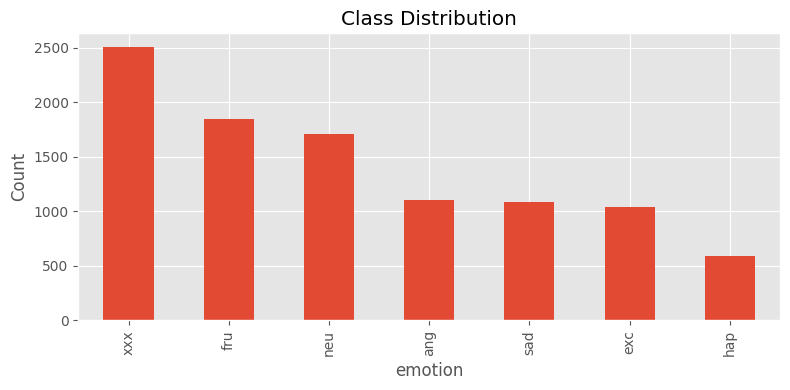

In [3]:
if not source_path.exists():
    raise FileNotFoundError(f'Missing source CSV: {source_path}')

df = pd.read_csv(source_path, nrows=USE_NROWS)

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Available: {list(df.columns[:20])}...")

meta_cols = [c for c in df.columns if c in METADATA_CANDIDATES]
feature_cols = [c for c in df.columns if c not in METADATA_CANDIDATES]

print(f'Data shape: {df.shape}')
print(f'Metadata columns ({len(meta_cols)}): {meta_cols}')
print(f'Feature columns ({len(feature_cols)}).')
print('Sample feature columns:', feature_cols[:10])

# quick class balance view
class_counts = df[TARGET_COL].value_counts(dropna=False)
print('Class distribution:')
print(class_counts)

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel(TARGET_COL)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4) Basic Cleaning and Train/Test Split

Rows with missing labels or missing feature values are removed.

In [4]:
model_df = df[[TARGET_COL] + feature_cols].copy()

rows_before = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COL])
model_df = model_df.dropna(axis=0, how='any')
rows_after = len(model_df)

X = model_df[feature_cols].astype(float)
y_raw = model_df[TARGET_COL].astype(str)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Rows before cleaning: {rows_before}')
print(f'Rows after cleaning:  {rows_after}')
print(f'Dropped rows:         {rows_before - rows_after}')
print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Classes: {list(label_enc.classes_)}')

Rows before cleaning: 9887
Rows after cleaning:  9887
Dropped rows:         0
Train shape: (7909, 1539)
Test shape:  (1978, 1539)
Classes: ['ang', 'exc', 'fru', 'hap', 'neu', 'sad', 'xxx']


## 5) Baseline Model (No Feature Selection)

A logistic regression baseline gives a reference before selection.

Baseline metrics (all models):
   stage         model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro
baseline        logreg    0.3711              0.3727           0.3711       0.3697    0.3721
baseline random_forest    0.3650              0.3770           0.3650       0.3427    0.3153
baseline    linear_svc    0.3428              0.3440           0.3428       0.3407    0.3462

[logreg] classification report (baseline):
              precision    recall  f1-score   support

         ang       0.43      0.49      0.46       221
         exc       0.37      0.39      0.38       208
         fru       0.41      0.39      0.40       370
         hap       0.19      0.29      0.23       119
         neu       0.39      0.39      0.39       342
         sad       0.43      0.49      0.46       217
         xxx       0.32      0.25      0.28       501

    accuracy                           0.37      1978
   macro avg       0.36      0.38      0.37      1978
weighted av

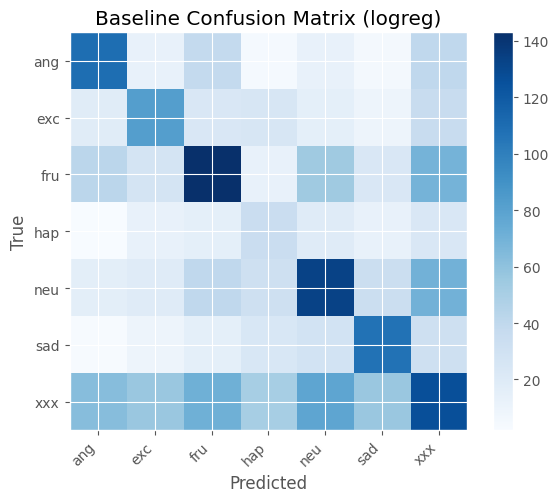

In [5]:
MODEL_SPECS = {
    'logreg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'linear_svc': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=8000)),
    ]),
    'random_forest': Pipeline([
        ('scaler', 'passthrough'),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}

all_labels = np.arange(len(label_enc.classes_))


@contextmanager
def tqdm_joblib(tqdm_object):
    # Patch joblib to report progress into tqdm bars.
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


def _resolve_model_jobs(requested_jobs: int, n_models: int) -> int:
    if requested_jobs == -1:
        return max(1, min(os.cpu_count() or 1, n_models))
    return max(1, min(int(requested_jobs), n_models))


def _has_inner_parallelism(estimator) -> bool:
    params = estimator.get_params(deep=True)
    if 'clf__n_jobs' not in params:
        return False
    return params['clf__n_jobs'] not in (None, 1)


def _fit_predict_single_model(
    model_name: str,
    estimator,
    X_train_eval,
    y_train_eval,
    X_test_eval,
    y_test_eval,
    stage_name: str,
    force_single_core_inner_model: bool,
):
    model = clone(estimator)

    # Prevent nested parallelism when models are already being run in parallel.
    if force_single_core_inner_model and 'clf__n_jobs' in model.get_params(deep=True):
        model.set_params(clf__n_jobs=1)

    model.fit(X_train_eval, y_train_eval)
    y_pred = model.predict(X_test_eval)

    row = {
        'stage': stage_name,
        'model': model_name,
        'accuracy': accuracy_score(y_test_eval, y_pred),
        'precision_weighted': precision_score(y_test_eval, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_test_eval, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test_eval, y_pred, average='weighted'),
        'f1_macro': f1_score(y_test_eval, y_pred, average='macro'),
    }
    return model_name, row, y_pred


def _evaluate_items_sequential(
    model_items,
    X_train_eval,
    y_train_eval,
    X_test_eval,
    y_test_eval,
    stage_name: str,
    desc: str,
    force_single_core_inner_model: bool,
):
    return [
        _fit_predict_single_model(
            model_name,
            estimator,
            X_train_eval,
            y_train_eval,
            X_test_eval,
            y_test_eval,
            stage_name,
            force_single_core_inner_model,
        )
        for model_name, estimator in tqdm(
            model_items,
            total=len(model_items),
            desc=desc,
            leave=False,
        )
    ]


def _evaluate_items_parallel(
    model_items,
    requested_jobs: int,
    X_train_eval,
    y_train_eval,
    X_test_eval,
    y_test_eval,
    stage_name: str,
    desc: str,
    force_single_core_inner_model: bool,
):
    if not model_items:
        return []

    n_jobs = _resolve_model_jobs(requested_jobs, len(model_items))
    if n_jobs == 1:
        return _evaluate_items_sequential(
            model_items,
            X_train_eval,
            y_train_eval,
            X_test_eval,
            y_test_eval,
            stage_name,
            desc,
            force_single_core_inner_model,
        )

    with tqdm_joblib(tqdm(total=len(model_items), desc=desc, leave=False)):
        return Parallel(n_jobs=n_jobs, backend='loky')(
            delayed(_fit_predict_single_model)(
                model_name,
                estimator,
                X_train_eval,
                y_train_eval,
                X_test_eval,
                y_test_eval,
                stage_name,
                force_single_core_inner_model,
            )
            for model_name, estimator in model_items
        )


def evaluate_models(X_train_eval, y_train_eval, X_test_eval, y_test_eval, stage_name: str):
    model_items = list(MODEL_SPECS.items())
    mode = str(MODEL_PARALLEL_MODE).strip().lower()
    if mode not in {'auto', 'outer', 'sequential'}:
        raise ValueError("MODEL_PARALLEL_MODE must be one of: auto, outer, sequential")

    requested_jobs = _resolve_model_jobs(MODEL_PARALLEL_JOBS, len(model_items))

    if mode == 'sequential' or requested_jobs == 1:
        evaluated = _evaluate_items_sequential(
            model_items,
            X_train_eval,
            y_train_eval,
            X_test_eval,
            y_test_eval,
            stage_name,
            desc=f'{stage_name}: train models',
            force_single_core_inner_model=False,
        )
    elif mode == 'outer':
        evaluated = _evaluate_items_parallel(
            model_items,
            requested_jobs,
            X_train_eval,
            y_train_eval,
            X_test_eval,
            y_test_eval,
            stage_name,
            desc=f'{stage_name}: train models',
            force_single_core_inner_model=True,
        )
    else:
        inner_parallel_items = [(name, est) for name, est in model_items if _has_inner_parallelism(est)]
        regular_items = [(name, est) for name, est in model_items if not _has_inner_parallelism(est)]

        evaluated = []
        if inner_parallel_items:
            evaluated.extend(
                _evaluate_items_sequential(
                    inner_parallel_items,
                    X_train_eval,
                    y_train_eval,
                    X_test_eval,
                    y_test_eval,
                    stage_name,
                    desc=f'{stage_name}: train inner-parallel models',
                    force_single_core_inner_model=False,
                )
            )

        if regular_items:
            evaluated.extend(
                _evaluate_items_parallel(
                    regular_items,
                    requested_jobs,
                    X_train_eval,
                    y_train_eval,
                    X_test_eval,
                    y_test_eval,
                    stage_name,
                    desc=f'{stage_name}: train models',
                    force_single_core_inner_model=False,
                )
            )

    rows = []
    preds = {}
    for model_name, row, y_pred in evaluated:
        preds[model_name] = y_pred
        rows.append(row)

    metrics_df = pd.DataFrame(rows).sort_values('f1_weighted', ascending=False, ignore_index=True)
    return metrics_df, preds


def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(range(len(label_enc.classes_)))
    ax.set_yticks(range(len(label_enc.classes_)))
    ax.set_xticklabels(label_enc.classes_, rotation=45, ha='right')
    ax.set_yticklabels(label_enc.classes_)
    plt.tight_layout()
    plt.show()


baseline_results, baseline_preds = evaluate_models(X_train, y_train, X_test, y_test, stage_name='baseline')

print('Baseline metrics (all models):')
print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in tqdm(
    baseline_results['model'],
    total=len(baseline_results),
    desc='baseline: classification reports',
    leave=False,
):
    print(f'\n[{model_name}] classification report (baseline):')
    print(classification_report(
        y_test,
        baseline_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_baseline_model = baseline_results.loc[0, 'model']
plot_confusion(y_test, baseline_preds[best_baseline_model], f'Baseline Confusion Matrix ({best_baseline_model})')

base_acc = float(baseline_results.loc[0, 'accuracy'])
base_f1 = float(baseline_results.loc[0, 'f1_weighted'])


## 6) PCA on Standardized Features

This cell standardizes train/test features, fits PCA on training data, and reports explained variance.


Original feature count: 1539
PCA component count:    300
Total explained variance: 0.9580
Top 10 PCA components by explained variance:
  component  explained_variance_ratio  cumulative_explained_variance
0  pca_0000                  0.572168                       0.572168
1  pca_0001                  0.068966                       0.641134
2  pca_0002                  0.041791                       0.682926
3  pca_0003                  0.028310                       0.711236
4  pca_0004                  0.021975                       0.733211
5  pca_0005                  0.014461                       0.747672
6  pca_0006                  0.011517                       0.759189
7  pca_0007                  0.009022                       0.768211
8  pca_0008                  0.007494                       0.775705
9  pca_0009                  0.007085                       0.782789


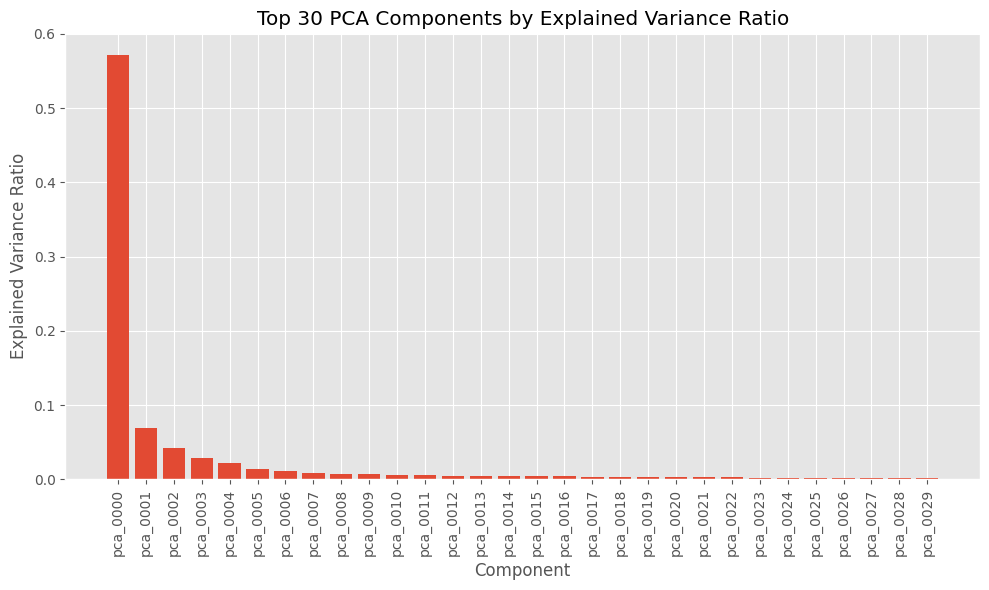

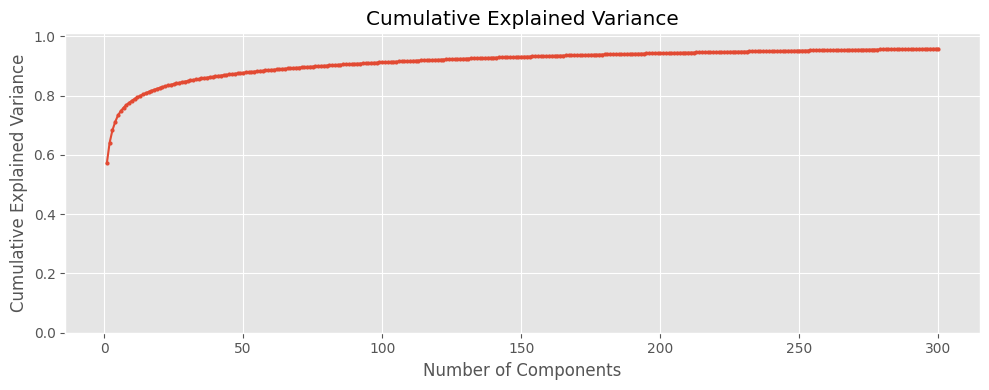

In [6]:
with tqdm(total=4, desc='pca: scale/fit/transform', leave=False) as pbar:
    scaler_for_pca = StandardScaler()
    X_train_scaled = scaler_for_pca.fit_transform(X_train)
    X_test_scaled = scaler_for_pca.transform(X_test)
    pbar.update(1)

    pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
    pca.fit(X_train_scaled)
    pbar.update(1)

    X_train_sel = pca.transform(X_train_scaled)
    X_test_sel = pca.transform(X_test_scaled)
    pbar.update(1)

    component_names = [f'pca_{i:04d}' for i in range(X_train_sel.shape[1])]
    selected_features = component_names
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)
    pbar.update(1)

print(f'Original feature count: {X_train.shape[1]}')
print(f'PCA component count:    {X_train_sel.shape[1]}')
print(f'Total explained variance: {cumulative[-1]:.4f}')

rank_df = pd.DataFrame({
    'component': component_names,
    'explained_variance_ratio': explained,
    'cumulative_explained_variance': cumulative,
})

print('Top 10 PCA components by explained variance:')
print(rank_df.head(10))

plot_n = min(30, len(rank_df))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(rank_df['component'][:plot_n], rank_df['explained_variance_ratio'][:plot_n])
ax.set_title(f'Top {plot_n} PCA Components by Explained Variance Ratio')
ax.set_xlabel('Component')
ax.set_ylabel('Explained Variance Ratio')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, len(cumulative) + 1), cumulative, marker='o', markersize=2)
ax.set_title('Cumulative Explained Variance')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_ylim(0, 1.01)
plt.tight_layout()
plt.show()


## 7) Model After PCA

Retrain all baseline models on PCA-transformed train/test data and compare metrics.


Post-PCA metrics (all models):
stage         model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro
  pca    linear_svc    0.3969              0.3968           0.3969       0.3817    0.3915
  pca        logreg    0.3837              0.3856           0.3837       0.3738    0.3859
  pca random_forest    0.3478              0.4282           0.3478       0.2962    0.2572

[linear_svc] classification report (post-pca):
              precision    recall  f1-score   support

         ang       0.42      0.58      0.49       221
         exc       0.38      0.48      0.43       208
         fru       0.44      0.34      0.38       370
         hap       0.18      0.25      0.21       119
         neu       0.41      0.46      0.44       342
         sad       0.46      0.71      0.56       217
         xxx       0.38      0.18      0.25       501

    accuracy                           0.40      1978
   macro avg       0.38      0.43      0.39      1978
weighted avg       

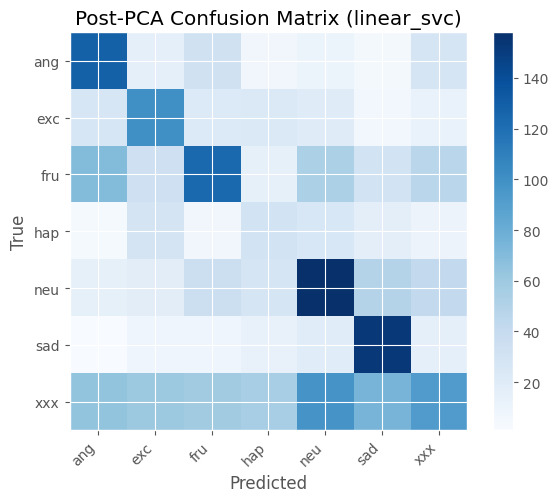


Metric delta by model (PCA - baseline):
        model  accuracy_baseline  precision_weighted_baseline  recall_weighted_baseline  f1_weighted_baseline  f1_macro_baseline  accuracy_selected  precision_weighted_selected  recall_weighted_selected  f1_weighted_selected  f1_macro_selected  accuracy_delta  precision_weighted_delta  recall_weighted_delta  f1_weighted_delta  f1_macro_delta
   linear_svc             0.3428                       0.3440                    0.3428                0.3407             0.3462             0.3969                       0.3968                    0.3969                0.3817             0.3915          0.0541                    0.0528                 0.0541             0.0410          0.0453
       logreg             0.3711                       0.3727                    0.3711                0.3697             0.3721             0.3837                       0.3856                    0.3837                0.3738             0.3859          0.0126            

In [7]:
selected_results, selected_preds = evaluate_models(
    X_train_sel,
    y_train,
    X_test_sel,
    y_test,
    stage_name='pca',
)

print('Post-PCA metrics (all models):')
print(selected_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for model_name in tqdm(
    selected_results['model'],
    total=len(selected_results),
    desc='pca: classification reports',
    leave=False,
):
    print(f'\n[{model_name}] classification report (post-pca):')
    print(classification_report(
        y_test,
        selected_preds[model_name],
        labels=all_labels,
        target_names=label_enc.classes_,
        zero_division=0,
    ))

best_selected_model = selected_results.loc[0, 'model']
plot_confusion(y_test, selected_preds[best_selected_model], f'Post-PCA Confusion Matrix ({best_selected_model})')

comparison_df = baseline_results[['model', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']].merge(
    selected_results[['model', 'accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'f1_macro']],
    on='model',
    suffixes=('_baseline', '_selected'),
)
comparison_df['accuracy_delta'] = comparison_df['accuracy_selected'] - comparison_df['accuracy_baseline']
comparison_df['precision_weighted_delta'] = comparison_df['precision_weighted_selected'] - comparison_df['precision_weighted_baseline']
comparison_df['recall_weighted_delta'] = comparison_df['recall_weighted_selected'] - comparison_df['recall_weighted_baseline']
comparison_df['f1_weighted_delta'] = comparison_df['f1_weighted_selected'] - comparison_df['f1_weighted_baseline']
comparison_df['f1_macro_delta'] = comparison_df['f1_macro_selected'] - comparison_df['f1_macro_baseline']
comparison_df = comparison_df.sort_values('f1_weighted_selected', ascending=False, ignore_index=True)

print('\nMetric delta by model (PCA - baseline):')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

sel_acc = float(selected_results.loc[0, 'accuracy'])
sel_f1 = float(selected_results.loc[0, 'f1_weighted'])


## 8) Save Artifacts

This exports PCA component names, explained variance table, and transformed train/test matrices.


In [8]:
out_dir = REPO_ROOT / 'feature_selection' / 'pca' / 'select_pca' / 'artifacts'
out_dir.mkdir(parents=True, exist_ok=True)

selected_feature_path = out_dir / f'{DATASET_KEY}_pca_components.json'
rank_path = out_dir / f'{DATASET_KEY}_pca_explained_variance.csv'
train_sel_path = out_dir / f'{DATASET_KEY}_X_train_pca.csv'
test_sel_path = out_dir / f'{DATASET_KEY}_X_test_pca.csv'
meta_path = out_dir / f'{DATASET_KEY}_run_metadata.json'

with tqdm(total=8, desc='artifacts: write outputs', leave=False) as pbar:
    with selected_feature_path.open('w', encoding='utf-8') as f:
        json.dump(selected_features, f, indent=2)
    pbar.update(1)

    rank_df.to_csv(rank_path, index=False)
    pbar.update(1)

    X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
    pbar.update(1)

    X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
    pbar.update(1)

    X_train_sel_df.to_csv(train_sel_path, index=False)
    pbar.update(1)

    X_test_sel_df.to_csv(test_sel_path, index=False)
    pbar.update(1)

    baseline_records = baseline_results.to_dict(orient='records')
    selected_records = selected_results.to_dict(orient='records')
    comparison_records = comparison_df.to_dict(orient='records')
    for collection in (baseline_records, selected_records, comparison_records):
        for row in collection:
            for key, value in list(row.items()):
                if isinstance(value, (np.floating, float)):
                    row[key] = float(value)
    pbar.update(1)

    run_meta = {
        'dataset_key': DATASET_KEY,
        'source_path': str(source_path),
        'target_col': TARGET_COL,
        'rows_used': int(len(model_df)),
        'original_features': int(X_train.shape[1]),
        'pca_components_config': PCA_COMPONENTS,
        'pca_components_effective': int(X_train_sel.shape[1]),
        'pca_explained_variance_total': float(cumulative[-1]),
        'random_state': RANDOM_STATE,
        'test_size': TEST_SIZE,
        'best_baseline_model': str(baseline_results.loc[0, 'model']),
        'best_pca_model': str(selected_results.loc[0, 'model']),
        'baseline_accuracy': float(base_acc),
        'baseline_f1_weighted': float(base_f1),
        'pca_accuracy': float(sel_acc),
        'pca_f1_weighted': float(sel_f1),
        'baseline_model_metrics': baseline_records,
        'pca_model_metrics': selected_records,
        'model_metric_deltas': comparison_records,
    }

    with meta_path.open('w', encoding='utf-8') as f:
        json.dump(run_meta, f, indent=2)
    pbar.update(1)

print('Saved artifacts:')
print('-', selected_feature_path)
print('-', rank_path)
print('-', train_sel_path)
print('-', test_sel_path)
print('-', meta_path)


Saved artifacts:
- F:\Speech-Emotion-Recognition\feature_selection\pca\select_pca\artifacts\ssl_hubert_pca_components.json
- F:\Speech-Emotion-Recognition\feature_selection\pca\select_pca\artifacts\ssl_hubert_pca_explained_variance.csv
- F:\Speech-Emotion-Recognition\feature_selection\pca\select_pca\artifacts\ssl_hubert_X_train_pca.csv
- F:\Speech-Emotion-Recognition\feature_selection\pca\select_pca\artifacts\ssl_hubert_X_test_pca.csv
- F:\Speech-Emotion-Recognition\feature_selection\pca\select_pca\artifacts\ssl_hubert_run_metadata.json


## 9) Notes for Next Methods

After this PCA baseline, common next folders/methods:
- `filter/select_k_best_anova/`
- `wrapper/rfe_logreg/`
- `embedded/l1_logreg/`
- `embedded/tree_importance/`


In [9]:
# Delta summary (PCA - baseline)
if 'comparison_df' not in globals():
    raise RuntimeError('comparison_df not found. Run the training/evaluation cells first.')

delta_cols = [
    'model',
    'accuracy_baseline',
    'accuracy_selected',
    'accuracy_delta',
    'precision_weighted_baseline',
    'precision_weighted_selected',
    'precision_weighted_delta',
    'recall_weighted_baseline',
    'recall_weighted_selected',
    'recall_weighted_delta',
    'f1_weighted_baseline',
    'f1_weighted_selected',
    'f1_weighted_delta',
    'f1_macro_baseline',
    'f1_macro_selected',
    'f1_macro_delta',
]

delta_table = comparison_df[delta_cols].copy().sort_values('f1_weighted_delta', ascending=False, ignore_index=True)

print('Delta table (PCA - baseline):')
print(delta_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nDelta accuracy only:')
print(
    delta_table[['model', 'accuracy_baseline', 'accuracy_selected', 'accuracy_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta precision only (weighted):')
print(
    delta_table[['model', 'precision_weighted_baseline', 'precision_weighted_selected', 'precision_weighted_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta recall only (weighted):')
print(
    delta_table[['model', 'recall_weighted_baseline', 'recall_weighted_selected', 'recall_weighted_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta weighted F1 only:')
print(
    delta_table[['model', 'f1_weighted_baseline', 'f1_weighted_selected', 'f1_weighted_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

best_gain_row = delta_table.iloc[0]
print(
    f"\nBest weighted-F1 delta after PCA: {best_gain_row['model']} | "
    f"Delta F1-weighted={best_gain_row['f1_weighted_delta']:+.4f}, "
    f"Delta Accuracy={best_gain_row['accuracy_delta']:+.4f}"
)


Delta table (PCA - baseline):
        model  accuracy_baseline  accuracy_selected  accuracy_delta  precision_weighted_baseline  precision_weighted_selected  precision_weighted_delta  recall_weighted_baseline  recall_weighted_selected  recall_weighted_delta  f1_weighted_baseline  f1_weighted_selected  f1_weighted_delta  f1_macro_baseline  f1_macro_selected  f1_macro_delta
   linear_svc             0.3428             0.3969          0.0541                       0.3440                       0.3968                    0.0528                    0.3428                    0.3969                 0.0541                0.3407                0.3817             0.0410             0.3462             0.3915          0.0453
       logreg             0.3711             0.3837          0.0126                       0.3727                       0.3856                    0.0129                    0.3711                    0.3837                 0.0126                0.3697                0.3738            